# Модель для предсказания массы морских черепах

- Автор: Шлыков Алексей
- Дата: 06.03.2025

## Цели и задачи проекта

Для центра исследования и реабилитации морских черепах разработать опытную модель линейной регрессии, использующую габариты и другие данные для предсказания массы черепах вида *Chelonia mydas*.  
Данная модель будет компонентом портативного прибора, использующего систему компьютерного зрения TurtleCV, бесконтактно замеряющего габариты черепах.    
Построенная модель будет обеспечивать высокую точность определения массы взрослых особей черепах; заметно сократит стресс для уязвимых животных; увеличит частоту и безопасность мониторинга их массы; позволит оптимизировать лечение и уход, повышая шансы на успешную реабилитацию; сделает возможным сбор более полных и точных данных для научного исследования популяций.  
По итогам тестирования будут изучены перспективы использования модели для предсказания массы других видов черепах.

## Постановка задачи машинного обучения

- Решить задачу линейно регресси.
- Предсказать целевую переменную по полю `'weight'` (вес).
- Использовать метрики качества MAE, MAPE, R2 в качестве основных
- Критерии эффективности модели для метрик:
    - MAE: не более 5кг для взрослых особей весом 50-150кг
    - R2 не менее 0.97

## Описание данных
Данные хранятся в CSV-файле и доступны по ссылке `turtles.csv`. Они содержат следующие поля:
- `id` — идентификатор измерения.
- `binomial_name` — международное научное название вида черепахи.
- `registration_number` — регистрационный номер черепахи.
- `shell_length` — длина панциря, мм.
- `shell_width` — ширина панциря, мм.
- `head_length` — длина головы, мм.
- `head_width` — ширина головы, мм.
- `flipper_length_n` — длина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо n указан номер от 1 до 4.
- `flipper_width_n` — ширина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях - вместо n указан номер от 1 до 4.
- `circle_count` — количество колец роста на панцире черепахи.
- `measure_count` — количество измерений, которые произвели, прежде чем усреднить показатели черепахи и добавить их в таблицу.
- `shell_crack` — наличие трещин панциря.
- `timestamp` — время внесения данных о черепахе.
- `weight` — масса черепахи, кг.

## Содержимое проекта
1. Подключение и настройка библиотек
2. Загрузка и знакомство с данными 
    - 2.1 Загрузка данных
    - 2.2 Подготовка данных
3. Исследовательский анализ данных
    - 3.1 Отбор нужных записей и признаков
    - 3.2 Обратботка пропусков и дубликатов
    - 3.3 Изучение распределения данных 
    - 3.4 Поиск и анализ корреляций
4. Предобработка данных
     - 4.1 Разделение данных на выборки
     - 4.2 Обработка пропусков
     - 4.3 Стадартизация и нормализация признаков
5. Обучение моделей
    - 5.1 Построение моделей
    - 5.2 Сравнение моделей на валидационной выборке
6. Проверка лучшей модели на тестовой выборке
7. Оценка важности признаков
8. Функция для прогнозирования веса черепахи
9. Общие выводы и рекомендации по дальнейшей работе

## 1.Подключение и настройка библиотек

In [1]:
# Импортируем необходимые библиотеки
import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
    SGDRegressor
)
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix

## 2.Загрузка и знакомство с данными 

### 2.1 Загрузка данных

In [2]:
# Загружаем данные
info_df = pd.read_csv("turtles.csv", sep='\t', decimal=',')

In [3]:
# Проверяем успешность загрузки, смотрим первые строки датасета
info_df.head()

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511


In [4]:
# Смотрим общие сведения о данных
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   object 
 2   registration number  8832 non-null   object 
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   i

**Промежуточный вывод:**
- Загружен датафрейм, состоящий из 20 столбцов и 8861 строки
- Названия и содержимое столбцов соответствуют описанию
- Данные содержат пропуски, необходима обработка
- Проверить данные на наличие дубликатов
- Название стобца `registration number` привести к snake_case
- Столбец `binomial_name`: необходимо привести названия видов к snake_case
- Столбцы с типом данных `float`: можно оптимизировать размерность
- Столбцы с типом данных `int`: можно оптимизировать размерность после обработки пропусков
- Столбец `timestamp` скорее всего содержит UNIX формат даты и времени, можно привести в интерпретируемый вид, присвоить тип данных `datetime`

### 2.2 Подготовка данных

In [5]:
# Создаем функцию для оптимизации числовых типов данных
def optimize_numeric(data):
    for column in data.columns:
        # Проверяем тип данных колонки
        if data[column].dtype == 'float64':
            try:
                data[column] = pd.to_numeric(data[column], downcast='float')
                print(f'Колонка {column} оптимизирована')
            # Если возникает ошибка, выведем ее причину
            except Exception as e: 
                print(f'Колонка {column} не может быть оптимизирована: {e}')
                
        elif data[column].dtype == 'int64':
            try:
                data[column] = pd.to_numeric(data[column], downcast='integer')
                print(f'Колонка {column} оптимизирована')
            except Exception as e:
                print(f'Колонка {column} не может быть оптимизирована: {e}')
    
    print('Оптимизация завершена' + '\n' + '-' * 100)

In [6]:
# Создаем функцию для первичного ознакомления с данными ()
def watchdata(data):
    print('Подсчет абсолютного количества пропусков:')
    display(data.isna().sum().sort_values(ascending=False)) 
    print('Всего пропусков:', data.isna().sum().sum())
    print('-'*100)
    
    print('Подсчет относительного количества пропусков:')
    # считаем долю пропусков в процентах
    display(data.isna().mean().sort_values(ascending=False)*100) 
    print('-'*100)
                  
    print('Подсчет дубликатов:')              
    dupl_count = data.duplicated().sum()        
    if dupl_count > 0:
        print(f'Количество дублей в датафрейме - {dupl_count}')
    else:
        print('Явные дубликаты отсутствуют')
    print('-'*100)
    
    print('Статистические метрики столбцов с численными данными:')             
    display(data.describe())
    print('-'*100)
    
    print('Общая информация по датафрейму:')
    display(data.info())
    
    return print('-'*100)

In [7]:
# Создаем функцию для приведения колонки к snake_case
def to_snake_case(df, column):
    df[column] = df[column].str.lower().str.strip().str.replace(' ', '_')
    print(f'Колонка приведена к snake_case')
    print('-'*100)

In [8]:
# Приведем название столбца к snake_case для унификации с оcтальными названиями
info_df = info_df.rename(columns={'registration number': 'registration_number'})
# Приведем столбец binomial_name к snake_case
to_snake_case(info_df, 'binomial_name')
# Делаем читаемым столбец с датой и  временем
info_df['timestamp'] = pd.to_datetime(info_df['timestamp'], unit='s')
# Оптимизируем колонки с числовыми типами данных
optimize_numeric(info_df)
# Выводим основную информацию по датасету, проверяем преобразования
watchdata(info_df)

Колонка приведена к snake_case
----------------------------------------------------------------------------------------------------
Колонка id оптимизирована
Колонка shell_length оптимизирована
Колонка shell_width оптимизирована
Колонка head_length оптимизирована
Колонка head_width оптимизирована
Колонка flipper_length_1 оптимизирована
Колонка flipper_width_1 оптимизирована
Колонка flipper_length_2 оптимизирована
Колонка flipper_width_2 оптимизирована
Колонка flipper_length_3 оптимизирована
Колонка flipper_width_3 оптимизирована
Колонка flipper_length_4 оптимизирована
Колонка flipper_width_4 оптимизирована
Колонка circle_count оптимизирована
Колонка measure_count оптимизирована
Колонка shell_crack оптимизирована
Колонка weight оптимизирована
Оптимизация завершена
----------------------------------------------------------------------------------------------------
Подсчет абсолютного количества пропусков:


shell_crack            6685
measure_count           264
head_length             146
head_width              146
flipper_width_4         101
flipper_length_3        101
flipper_width_3         101
flipper_length_4        101
shell_length             87
binomial_name            49
registration_number      29
weight                   19
timestamp                 0
circle_count              0
id                        0
flipper_length_2          0
flipper_width_1           0
flipper_length_1          0
shell_width               0
flipper_width_2           0
dtype: int64

Всего пропусков: 7829
----------------------------------------------------------------------------------------------------
Подсчет относительного количества пропусков:


shell_crack            75.442952
measure_count           2.979348
head_length             1.647670
head_width              1.647670
flipper_width_4         1.139826
flipper_length_3        1.139826
flipper_width_3         1.139826
flipper_length_4        1.139826
shell_length            0.981830
binomial_name           0.552985
registration_number     0.327277
weight                  0.214423
timestamp               0.000000
circle_count            0.000000
id                      0.000000
flipper_length_2        0.000000
flipper_width_1         0.000000
flipper_length_1        0.000000
shell_width             0.000000
flipper_width_2         0.000000
dtype: float64

----------------------------------------------------------------------------------------------------
Подсчет дубликатов:
Количество дублей в датафрейме - 1019
----------------------------------------------------------------------------------------------------
Статистические метрики столбцов с численными данными:


,id,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,weight
count,8861.000000,8774.000000,8861.000000,8715.000000,8715.000000,8861.000000,8861.000000,8861.000000,8861.000000,8760.000000,8760.000000,8760.000000,8760.000000,8861.000000,8597.000000,2176.000000,8842.000000
mean,21359.335628,764.222046,598.832299,123.341019,115.735168,497.551405,380.594515,498.228530,380.687507,397.953186,304.405243,397.853210,305.030029,41.002821,2.477143,1.671415,79.163025
std,2263.089420,640.408264,480.970492,67.836578,62.326366,353.575213,214.481679,355.074883,213.485239,282.970612,171.172440,281.983307,171.540588,36.995874,1.116578,1.131782,95.877579
min,17438.000000,132.000000,78.000000,19.000000,12.000000,60.000000,34.000000,57.000000,33.000000,50.000000,27.000000,44.000000,25.000000,0.000000,1.000000,1.000000,0.000000
25%,19396.000000,440.000000,341.000000,73.000000,67.000000,296.000000,228.000000,296.000000,229.000000,239.000000,182.000000,236.000000,183.000000,0.000000,1.000000,1.000000,31.109499
50%,21357.000000,635.000000,487.000000,106.000000,98.000000,416.000000,332.000000,417.000000,330.000000,333.000000,264.000000,333.000000,266.000000,35.000000,2.000000,1.000000,41.140499
75%,23317.000000,951.000000,794.000000,158.000000,156.000000,571.000000,493.000000,572.000000,500.000000,457.000000,397.000000,456.000000,396.000000,73.000000,3.000000,2.000000,85.239502
max,25279.000000,20240.000000,11550.000000,515.000000,382.000000,2875.000000,1479.000000,2967.000000,1402.000000,2279.000000,1280.000000,2406.000000,1313.000000,178.000000,4.000000,5.000000,617.776978


----------------------------------------------------------------------------------------------------
Общая информация по датафрейму:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   8861 non-null   int16         
 1   binomial_name        8812 non-null   object        
 2   registration_number  8832 non-null   object        
 3   shell_length         8774 non-null   float32       
 4   shell_width          8861 non-null   int16         
 5   head_length          8715 non-null   float32       
 6   head_width           8715 non-null   float32       
 7   flipper_length_1     8861 non-null   int16         
 8   flipper_width_1      8861 non-null   int16         
 9   flipper_length_2     8861 non-null   int16         
 10  flipper_width_2      8861 non-null   int16         
 11  flipper_length

None

----------------------------------------------------------------------------------------------------


**Промежуточный вывод:**
- Проведена оптимизация столбцов с численными типами данных
- Столбец `timestamp` приведен в удобный для человека вид
- Перед проверкой на дубликаты названия колонок и тестовые данные были приведены к общему виду snake_case
- Пропусков: 7829
- Дубликатов: 1019 (11% от общего числа данных)

## 3. Исследовательский анализ данных

Проведите исследовательский анализ данных:
1. Выясните, данные о каких черепахах представлены в датасете.
2. Проведите отбор записей о нужном виде черепах. Для дальнейшей работы достаточно изучить только *Chelonia mydas*. При этом вы можете сравнить распределение данных об этих черепахах с другими видами, если есть желание и время.
3. Определите, все ли признаки можно использовать для решения задачи. Ответ обоснуйте. Удалите признаки, которые вам никак не помогут.
4. Проверьте, есть ли в данных пропуски. Определите, какие из них можно обработать сразу, а в каких случаях лучше сперва провести разделение на выборки. Решите, стоит ли удалить некоторые пропуски.
5. Определите, есть ли в данных дубликаты. Выберите корректный способ их обработки.
6. Проанализируйте распределение признаков, постройте необходимые для этого визуализации: ящики с усами, гистограммы и так далее. Определите, есть ли в данных выбросы и какие из них критичные. Решите, можно ли их сразу исправить.
7. Проверьте, одинаков ли масштаб признаков. Если он различается, предложите решение этой проблемы.
8. Проанализируйте корреляцию между признаками и целевой переменной с помощью вычислений и графически. Определите, все ли признаки нужны для дальнейшей работы.
9. Проверьте данные на мультиколлинеарность и решите, можно ли её устранить.

### 3.1 Отбор нужных записей и признаков

In [9]:
# Смотрим какие названия видов присутствуют в датасете
info_df['binomial_name'].value_counts()

lepidochelys_olivacea     4215
chelonia_mydas            2829
caretta_caretta            847
dermochelys_coriacea       484
eretmochelys_imbricata     409
lepidochelys_kempii         28
Name: binomial_name, dtype: int64

In [10]:
# Отберем только те строки, которые содержат вид Chelonia mydas
df = info_df.loc[info_df['binomial_name'] == 'chelonia_mydas']

In [11]:
# Выведем данные по обновленному датасету
watchdata(df)

Подсчет абсолютного количества пропусков:


shell_crack            2152
measure_count            81
head_length              39
head_width               39
shell_length             35
flipper_length_4         31
flipper_width_4          31
flipper_length_3         31
flipper_width_3          31
registration_number       4
weight                    3
timestamp                 0
circle_count              0
id                        0
binomial_name             0
flipper_length_2          0
flipper_width_1           0
flipper_length_1          0
shell_width               0
flipper_width_2           0
dtype: int64

Всего пропусков: 2477
----------------------------------------------------------------------------------------------------
Подсчет относительного количества пропусков:


shell_crack            76.069282
measure_count           2.863203
head_length             1.378579
head_width              1.378579
shell_length            1.237186
flipper_length_4        1.095794
flipper_width_4         1.095794
flipper_length_3        1.095794
flipper_width_3         1.095794
registration_number     0.141393
weight                  0.106045
timestamp               0.000000
circle_count            0.000000
id                      0.000000
binomial_name           0.000000
flipper_length_2        0.000000
flipper_width_1         0.000000
flipper_length_1        0.000000
shell_width             0.000000
flipper_width_2         0.000000
dtype: float64

----------------------------------------------------------------------------------------------------
Подсчет дубликатов:
Количество дублей в датафрейме - 341
----------------------------------------------------------------------------------------------------
Статистические метрики столбцов с численными данными:


,id,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,weight
count,2829.000000,2794.000000,2829.000000,2790.000000,2790.000000,2829.000000,2829.000000,2829.000000,2829.000000,2798.000000,2798.000000,2798.000000,2798.000000,2829.000000,2748.000000,677.000000,2826.000000
mean,21321.534464,1052.253784,948.835277,170.202515,183.487091,613.509721,550.534464,613.161895,551.920467,488.573975,441.146545,489.997131,441.663696,81.087310,2.495633,1.771049,96.460556
std,2260.214349,582.267090,519.814403,41.944279,45.950962,143.814403,133.707295,139.846498,131.851910,111.590858,106.100082,113.576141,105.383362,16.378258,1.108415,1.261349,35.540405
min,17438.000000,645.000000,564.000000,87.000000,96.000000,339.000000,245.000000,327.000000,276.000000,282.000000,231.000000,254.000000,243.000000,29.000000,1.000000,1.000000,0.000000
25%,19324.000000,837.000000,753.000000,138.000000,148.000000,503.000000,449.000000,505.000000,450.000000,400.000000,357.000000,400.250000,359.000000,70.000000,2.000000,1.000000,67.682999
50%,21354.000000,978.500000,889.000000,164.000000,176.000000,588.000000,527.000000,590.000000,534.000000,473.000000,426.000000,472.000000,423.000000,80.000000,3.000000,1.000000,87.930496
75%,23273.000000,1177.750000,1060.000000,196.000000,212.000000,702.000000,634.000000,707.000000,637.000000,560.000000,511.000000,565.000000,510.000000,91.000000,3.000000,2.000000,118.335999
max,25276.000000,12840.000000,11550.000000,328.000000,382.000000,1147.000000,1072.000000,1049.000000,997.000000,934.000000,837.000000,877.000000,806.000000,143.000000,4.000000,5.000000,199.960999


----------------------------------------------------------------------------------------------------
Общая информация по датафрейму:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2829 entries, 8 to 8859
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   2829 non-null   int16         
 1   binomial_name        2829 non-null   object        
 2   registration_number  2825 non-null   object        
 3   shell_length         2794 non-null   float32       
 4   shell_width          2829 non-null   int16         
 5   head_length          2790 non-null   float32       
 6   head_width           2790 non-null   float32       
 7   flipper_length_1     2829 non-null   int16         
 8   flipper_width_1      2829 non-null   int16         
 9   flipper_length_2     2829 non-null   int16         
 10  flipper_width_2      2829 non-null   int16         
 11  flipper_length

None

----------------------------------------------------------------------------------------------------


In [12]:
# Сохраняем в переменную количество строк в датасете для удобства дальнейших расчетов
rows = df.shape[0]

In [13]:
# Удаляем столбцы с данными, которые не пригодятся при построении модели
df = df.drop(columns=['id', 'binomial_name', 'registration_number', 'measure_count', 'timestamp'])

Из датасета были удалены содержащие id, название вида, регистрационный номер, количество измерений, дату и время проведения замеров. Эти признаки не пригодятся нам при построении модели и будут излишне ее перегружать.

Обоснование: id и регистрационный номер - это техническая информация, название вида нам не нужно, так как модель не будет строится только для одного вида черепах, количество измерений не нужно - в признаках уже указано среднее, дату и время не будем учитывать, так как предполагаем, что измерения проводились технически исправным прибором. Внимание стоит обратить также на признак `shell_crack`, трещины в панцире могут возникать по естественным причинам и не зависить от массы тела. Примем решение по этому признаку после изучения корреляции с целевой переменной.

Таким образом в датасете остаются только признаки, которые содержат только данных об измерениях черепах.

### 3.2 Обработка пропусков и дубликатов

Столбцы с измерениями `measure_count`, `head_width`, `head_length`, `shell_length`, `flipper_length_3`, `flipper_width_3`, `flipper_width_4`, `flipper_length_4`, `weight` содержат небольшое количество пропусков (0.1-2.9%), их можно заменить на средние значения, которые будут вычислены по обучающей выборке, чтобы не допустить утечки данных. На этом этапе пропуски оставим без изменений.

Столбец с целевой переменной `weight` содержит 3 пропуска, их лучше удалить, также столбец `weight` имеет минимальное значение 0.0: так быть не может, необходимо проверить эти данные.

Наибольшее число пропусков (76%) содержится в столбце `shell_crack`. Гипотеза: пропуски вносились тогда, когда не были обнаружены трещины на панцире. 

In [14]:
# Удаляем пропуски из столбца с целевой переменной
df = df.dropna(subset=['weight'])

In [15]:
# Подсчитаем количество строк с нулевым значением
weight_zero = df.loc[df['weight'] == 0.]
print(f'Строк с нулевым значением веса:', weight_zero.shape[0]) 

Строк с нулевым значением веса: 3


Всего 3 строки, эти данные можно удалить.

In [16]:
# Удаляем строки
df = df.loc[df['weight'] != 0.0]

In [17]:
# Смотрим уникальные значение в столбце с информацией о трещинах в панцире
df['shell_crack'].value_counts(dropna=False)  

NaN    2149
1.0     437
2.0      89
3.0      67
5.0      56
4.0      25
Name: shell_crack, dtype: int64

Вывод: гипотеза подтверждается, в столбце не обнаружено значение 0.0. Также логично, что у большинства исследованных черепах (2152) трещины должны отсутствовать. Нужно заменить пропуски на значение 0.0 для продолжения дальнейшей работы.

In [18]:
# Заменяем пропуски на нулевое значение
df['shell_crack'] = df['shell_crack'].fillna(0.0)

В датасете были найдены дубликаты (341), их нужно удалить.

In [19]:
# Удаляем дубликаты данных
df = df.drop_duplicates()

### 3.3 Изучение распределения данных

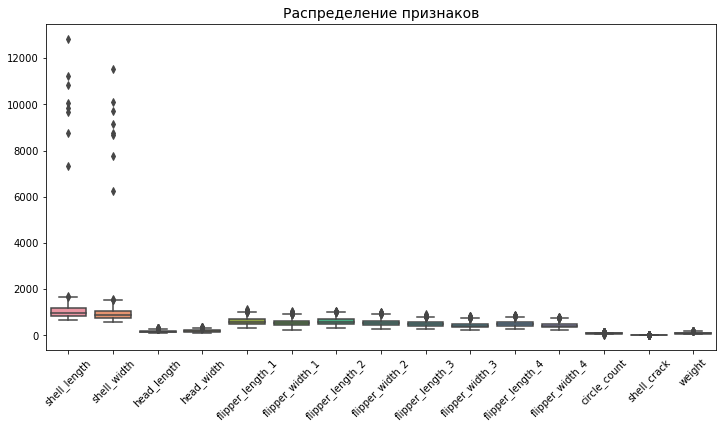

In [20]:
# Визуализируем распределение признаков
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.title('Распределение признаков', fontsize=14)
plt.xticks(rotation=45)
plt.show()

От заказчика нам известно, что часть данных при внесении были ошибно перемножены на 10. Необходимо найти эти записи и восстановить правильные значения. Судя по наличию экстремальных выбросов в колонках `shell_length` и `shell_width` начать стоит именно с этих столбцов. В данном случае будет оправдано воспользоваться формулой q3 + 3 * iqr, так как она используется для обнаружения сильных выбросов. Этот метод устойчив к распределению данных (не требует нормальности) и автоматически подстраивается под разброс значений. 

In [21]:
# Напишем функцию, фильтрующие данные по формуле q3 + 3 * iqr процентилю и возвращающую значения в мм
def filter_iqr(data, columns):
    for column in columns:
        q1 = data[column].quantile(0.25)
        q3 = data[column].quantile(0.75)
        iqr = q3 - q1
        upper_bound = q3 + 3 * iqr
        data.loc[data[column] >= upper_bound, column] = data.loc[data[column] >= upper_bound, column] / 10
    return data

In [22]:
df1 = filter_iqr(df, ['shell_length', 'shell_width'])


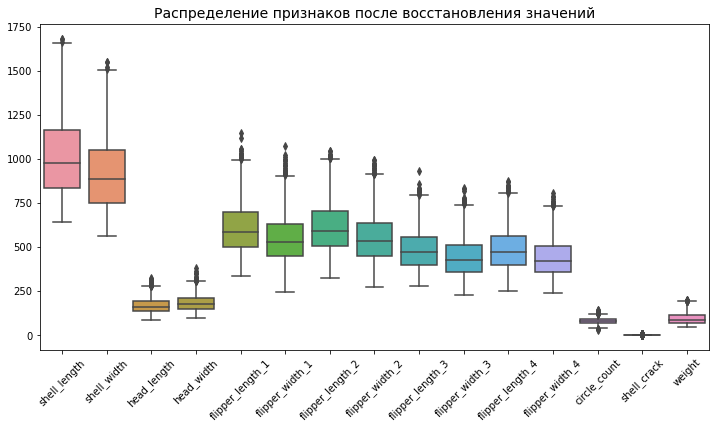

In [23]:
# Визуализируем распределение признаков после восстановления значений
plt.figure(figsize=(12,6))
sns.boxplot(data=df1)
plt.title('Распределение признаков после восстановления значений', fontsize=14)
plt.xticks(rotation=45)
plt.show()

Удалось избавится от выбросов по верхней границе столбцов `shell_length` и `shell_width`, распределение данных в остальных столбцах выглядит реалистично, дополнительных действий не требуется.    

In [24]:
df1.describe()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,shell_crack,weight
count,2454.000000,2483.000000,2448.000000,2448.000000,2483.000000,2483.000000,2483.000000,2483.000000,2454.000000,2454.000000,2454.000000,2454.000000,2483.000000,2483.000000,2483.000000
mean,1018.386292,918.886830,169.714462,183.311676,611.919855,549.349577,611.838905,550.203786,487.223724,440.602692,489.198456,440.934814,80.923882,0.420056,96.184906
std,222.000320,203.164503,41.305340,45.467590,142.471085,131.829439,138.925759,130.881637,110.375633,105.505745,112.575081,104.512001,16.227341,0.960719,35.011532
min,645.000000,564.000000,87.000000,96.000000,339.000000,245.000000,327.000000,276.000000,282.000000,231.000000,254.000000,243.000000,29.000000,0.000000,49.044998
25%,837.000000,751.500000,138.000000,148.000000,501.500000,449.000000,504.500000,449.000000,400.000000,357.000000,400.000000,359.000000,70.000000,0.000000,67.538002
50%,979.500000,887.000000,163.000000,176.000000,587.000000,527.000000,591.000000,533.000000,473.000000,425.000000,473.000000,423.000000,80.000000,0.000000,87.950996
75%,1167.750000,1054.000000,195.000000,212.000000,702.000000,632.000000,704.000000,635.000000,558.000000,511.000000,563.000000,508.750000,91.000000,0.000000,117.638500
max,1683.000000,1554.000000,328.000000,382.000000,1147.000000,1072.000000,1049.000000,997.000000,934.000000,837.000000,877.000000,806.000000,143.000000,5.000000,199.960999


Анализ описательных статистик показал, что признаки имеют разный масштаб. Например, средняя длина панциря составляет 1018 мм, в то время как среднее количество колец роста (circle_count) равно 81. Такое различие может привести к нестабильности коэффициентов линейной регрессии. Для устранения этой проблемы на этапе предобработки будет применено масштабирование числовых признаков.

### 3.3 Поиск и анализ корреляций

interval columns not set, guessing: ['shell_length', 'shell_width', 'head_length', 'head_width', 'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'circle_count', 'shell_crack', 'weight']


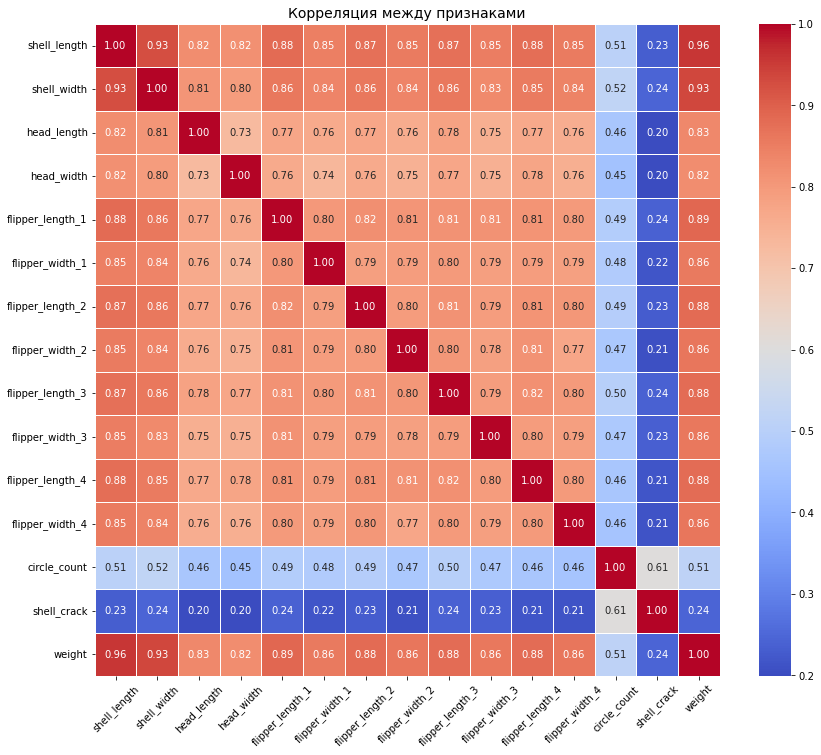

In [25]:
# Создаем и визуализируем корреляционную матрицу
corr_columns=df1[list(df1.columns)]
corr_matrix = corr_columns.phik_matrix()
plt.figure(figsize=(14,12))
sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='coolwarm')
plt.title('Корреляция между признаками', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

Анализ корреляции Phik выявил, что большинство линейных размеров (длины и ширины панциря, головы, ласт) имеют высокую положительную корреляцию с целевой переменной `weight` (>0.8), что подтверждает их предсказательную силу. Признак `circle_count` также показал высокую корреляцию (0.83), подтверждая теоретические сведения о связи колец роста с массой. Признак `shell_crack` продемонстрировал низкую корреляцию с весом (0.24) и будет удален из дальнейшего рассмотрения как неинформативный.

In [26]:
# Удаляем неинформативный столбец
df1 = df1.drop(columns='shell_crack')

In [27]:
# Содаем функцию для подсчета удаленных строк
def deleted_rows(initial_rows, new_rows):
    deleted = initial_rows - new_rows
    del_share = round((deleted / initial_rows) * 100, 2)
    return f'Всего было удалено {deleted} строк, что составляет {del_share}% данных'

df1_rows = df1.shape[0] # Число строк после удаления
# Подсчитаем абсолютное и относительное количество удаленных строк
deleted_rows(rows, df1_rows)

'Всего было удалено 346 строк, что составляет 12.23% данных'

Обнаружена высокая мультиколлинеарность между признаками, особенно внутри групп, описывающих панцирь (`shell_length`, `shell_width`) и ласты (все 4 длины и ширины). Это проявляется в значениях корреляции, превышающих 0.9. Для обеспечения устойчивости линейной модели будет применен отбор признаков: на этапе предобработки мы оставим по одному наиболее репрезентативному признаку из групп (например, `shell_length`и `flipper_length_1`), чтобы уменьшить дублирование информации. Альтернативой может стать использование регуляризованных моделей (`Ridge`, `Lasso`) на этапе обучения, а также замена части признаков на сконструированные(площадь головы и площадь конечностей) для чего будет создан отдельный датасет.

**Промежуточный вывод:**
- Создан датасет, включающий в себя только черепах вида 'chelonia_mydas'
- Удалены столбцы-признаки, которые не несут пользы для построения модели
- Удалено 346 строк (12.23% от отобранных данных), содержащие дубликаты и невозможные значения
- Восстановлены некорректно внесенные значения некоторых признаков
- Проведен анализ описательных статистик признаков, обнаружены различия в масштабах признаков
- Проведен анализ корреляции признаков:
    - Линейные размеры показывают высокую степень корреляции (>0.8) с целевой переменной
    - Обнаружена высокая мультиколлинеарность между признаками

## 4. Предобработка данных

1. Разделите данные на выборки: обучающую (60%), валидационную (20%) и тестовую (20%). В реальных проектах стараются писать код предобработки так, чтобы предотвратить утечку данных. Это проще сделать, если сразу поделить данные.
2. Обработайте пропуски. При необходимости заполните их средними (медианными) значениями. Рассчитайте заполнитель только по обучающей выборке: это ещё одно правило для предотвращения утечки.
3. Напишите функцию для стандартизации признаков. Расчёт параметров масштабирования делайте только по обучающей выборке, чтобы не дать утечке ни малейшего шанса.
4. Напишите функцию для нормализации признаков.
5. Подготовьте несколько датасетов из трёх выборок каждый для дальнейшего обучения моделей с разным способом масштабирования: без масштабирования, с нормализацией, со стандартизацией.

### 4.1 Разделение данных на выборки

In [28]:
# Разделим данные на выборки: обучающую (60%), валидационную (20%) и тестовую (20%)

# Создаем датасет с признаками
X = df1.drop(columns='weight')
# Создаем датасет с целевой переменной
y = df1['weight']
# Выделяем тестовую выборку
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)
# Из оставшихся данных выделяем валидационную выборку
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, shuffle=True, random_state=42)

print(f'Размеры выборок: Обучающая: {len(X_train)} Валидационная: {len(X_val)}\nТестовая: {len(X_test)}')

Размеры выборок: Обучающая: 1489 Валидационная: 497
Тестовая: 497


### 4.2 Обработка пропусков

In [29]:
# Вычисляем среднее знаечение по обучающей выборке
mean_values = X_train.mean()
X_train = X_train.fillna(mean_values)

In [30]:
# Создаем функцию для замены пропусков средними значениями
def replace_mean(train, val, test):
    # Вычисляем средние знаечение по обучающей выборке
    X_mean_values = train.mean()
    # Заменяем пропуски
    train = train.fillna(mean_values)
    val = val.fillna(mean_values)
    test = test.fillna(mean_values)
    return train, val, test

In [31]:
# Обрабатываем пропуски в признаках
X_train, X_val, X_test = replace_mean(X_train, X_val, X_test)

### 4.3 Стадартизация и нормализация признаков

In [32]:
# Напишем функцию для стандартизации признаков
def scale_standard(train, val, test):
    mean = train.mean()
    std = train.std()
    train_standard = (train - mean) / std
    val_standard = (val - mean) / std
    test_standard = (test - mean) / std
    return train_standard, val_standard, test_standard

In [33]:
# Создаем функцию для нормализации признаков
def scale_minmax(train, val, test):
    min_vals = train.min()
    max_vals = train.max()
    train_minmax = (train - min_vals) / (max_vals - min_vals)
    val_minmax = (val - min_vals) / (max_vals - min_vals)
    test_minmax = (test - min_vals) / (max_vals - min_vals)
    return train_minmax, val_minmax, test_minmax

In [34]:
# Создаем стндартизированные признаки
X_train_std, X_val_std, X_test_std = scale_standard(X_train, X_val, X_test)

In [35]:
# Создаем нормализованные признаки 
X_train_minmax, X_val_minmax, X_test_minmax = scale_minmax(X_train, X_val, X_test)

**Промежуточный вывод:**
- Данные были разделены на три выборки: обучающую, валидационную и тестовую.
- Пропуски были заменены на средние значения, вычисленные по обучающей выборке
- Подготовлено три группы выборок, где:
    1. Исходные признаки (X_train, X_val, X_test)
    2. Стандартизованные признаки (X_train_std, X_val_std, X_test_std)
    3. Нормализованные признаки (X_train_minmax, X_val_minmax, X_test_minmax)

## 5. Обучение моделей

### 5.1 Построение линейных моделей 

In [36]:
# Построим базовую модель
dummy = DummyRegressor(strategy = 'mean')
dummy.fit(None, y_train)
y_pred_dummy = dummy.predict(X_val)
# Оцениваем качество
mae_dummy = mean_absolute_error(y_val, y_pred_dummy)
mape_dummy = mean_absolute_percentage_error(y_val, y_pred_dummy)
r2_dummy = r2_score(y_val, y_pred_dummy)
print(f"\nLinearRegression → MAE: {mae_dummy:.4f}, R2: {r2_dummy:.4f}, MAPE: {mape_dummy:.4f}")


LinearRegression → MAE: 29.3529, R2: -0.0029, MAPE: 0.3244


Построена базовая модель, предсказывающая среднее значение по обучающей выборке, для сравнения с последующими.

Так как объем данных у нас достаточно невелик (1489 строк в обучающей выборке), то имеет смысл начать с аналитического решения.

In [37]:
# Аналитическое решение

# Обучаем LinearRegression на обучающей выборке
lr = LinearRegression()
lr.fit(X_train, y_train)

# Предсказываем на валидационной выборке
y_pred_lr = lr.predict(X_val)

# Оцениваем качество
mae_lr = mean_absolute_error(y_val, y_pred_lr)
r2_lr = r2_score(y_val, y_pred_lr)
mape_lr = mean_absolute_percentage_error(y_val, y_pred_lr)

print(f"\nLinearRegression → MAE: {mae_lr:.4f}, R2: {r2_lr:.4f}, MAPE: {mape_lr:.4f}")


LinearRegression → MAE: 3.8969, R2: 0.9804, MAPE: 0.0428


- Аналитическое решение показывает хороший результат на валидационной выборке и существенно превосходит предсказания базовой модели(MAE улучшается на 25.46, R2 улучшается на 0.98)
- Далее посторим еще несколько моделей и постараемся еще улучшить качество предсказаний.

На предыдущем этапе мы установили, что признаки обладают высокой степенью мультиколлинеарности, также все признаки имееют сильную корреляцию с целевой переменной. В этом случае подходит L2 Ridge регуляризация, она поможет сгладить веса и сделать модель более стабильной.   

Мы построим две модели, которые будут использовать масштабированные признаки, c перебором значений гиперпараметра alpha 

In [38]:
# Модель Ridge, масштабирование minmax

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000] # Задаем шаг перебора по логарифмической шкале

best_alpha = None
best_mae_ridge = float('inf')
ridge_final = None  # переменная для лучшей модели

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_minmax, y_train)
    y_pred_ridge = ridge.predict(X_val_minmax)
    mae_ridge = mean_absolute_error(y_val, y_pred_ridge)
    
    print(f"Alpha: {alpha:.2f}, Validation MAE: {mae_ridge:.4f}")  # исправлено
    
    # Сохраняем лучшую модель
    if mae_ridge < best_mae_ridge:  
        best_mae_ridge = mae_ridge
        best_alpha = alpha
        ridge_minmax_final = ridge  # сохраняем объект модели

print(f"\nЛучший alpha по валидации: {best_alpha}")

# Теперь ridge_minmax_final — это обученная модель с оптимальным alpha
y_pred_ridge_minmax = ridge_minmax_final.predict(X_val_minmax)
mae_ridge_minmax = mean_absolute_error(y_val, y_pred_ridge_minmax)
r2_ridge_minmax = r2_score(y_val, y_pred_ridge_minmax)
mape_ridge_minmax = mean_absolute_percentage_error(y_val, y_pred_ridge_minmax)

print(f"Ridge → MAE: {mae_ridge_minmax:.4f}, R2: {r2_ridge_minmax:.4f}, MAPE: {mape_ridge_minmax:.4f}") 

Alpha: 0.00, Validation MAE: 3.8969
Alpha: 0.01, Validation MAE: 3.8969
Alpha: 0.10, Validation MAE: 3.8965
Alpha: 1.00, Validation MAE: 3.9047
Alpha: 10.00, Validation MAE: 4.0257
Alpha: 100.00, Validation MAE: 5.8194
Alpha: 1000.00, Validation MAE: 19.2579

Лучший alpha по валидации: 0.1
Ridge → MAE: 3.8965, R2: 0.9804, MAPE: 0.0428


Модель с регуляризацией Ridge, использующая нормализованные признаки, показала результат, практически идентичный линейной регрессии (MAE улучшилось на 0.0004, R² без изменений). Это ожидаемо, так как при слабой регуляризации (alpha=0.1) Ridge приближается к обычной линейной регрессии.

In [39]:
# Модель Ridge, масштабирование std

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000] # Задаем шаг перебора по логарифмической шкале

best_alpha = None
best_mae_ridge = float('inf')
ridge_final = None  # переменная для лучшей модели

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_std, y_train)
    y_pred_ridge = ridge.predict(X_val_std)
    mae_ridge = mean_absolute_error(y_val, y_pred_ridge)
    
    print(f"Alpha: {alpha:.2f}, Validation MAE: {mae_ridge:.4f}")  # исправлено
    
    # Сохраняем лучшую модель
    if mae_ridge < best_mae_ridge:  
        best_mae_ridge = mae_ridge
        best_alpha = alpha
        ridge_std_final = ridge  # сохраняем объект модели

print(f"\nЛучший alpha по валидации: {best_alpha}")

# Теперь ridge_std_final — это обученная модель с оптимальным alpha
y_pred_ridge_std = ridge_std_final.predict(X_val_std)
mae_ridge_std = mean_absolute_error(y_val, y_pred_ridge_std)
r2_ridge_std = r2_score(y_val, y_pred_ridge_std)
mape_ridge_std = mean_absolute_percentage_error(y_val, y_pred_ridge_std)

print(f"Ridge → MAE: {mae_ridge_std:.4f}, R2: {r2_ridge_std:.4f}, MAPE: {mape_ridge_std:.4f}") 

Alpha: 0.00, Validation MAE: 3.8969
Alpha: 0.01, Validation MAE: 3.8969
Alpha: 0.10, Validation MAE: 3.8969
Alpha: 1.00, Validation MAE: 3.8967
Alpha: 10.00, Validation MAE: 3.8998
Alpha: 100.00, Validation MAE: 3.9861
Alpha: 1000.00, Validation MAE: 4.3753

Лучший alpha по валидации: 1
Ridge → MAE: 3.8967, R2: 0.9804, MAPE: 0.0428


Результат на стандартизированных признаках оказался идентичным нормализованным. Можем сделать вывод, что при небольших значениях гиперпараметра alpha тип масштабирования не оказывает значимого влияния на качество предсказаний.

Попробуем поменять метод регуляризации c Ridge на Lasso. Аналогично предыдущим моделям будет использован перебор гиперпараметра alpha для подбора наилучшего значения. В модели будут использоваться нормализованные minmax признаки. 

In [40]:
# Модель Lasso, масштабирование minmax

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000] # Задаем шаг по логарифмической шкале

best_alpha = None
best_mae_lasso = float('inf')
lasso_final = None  # переменная для лучшей модели

for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_minmax, y_train)
    y_pred_lasso = lasso.predict(X_val_minmax)
    mae_lasso = mean_absolute_error(y_val, y_pred_lasso)
    
    print(f"Alpha: {alpha:.2f}, Validation MAE: {mae_lasso:.4f}") 
    
    # Сохраняем лучшую модель
    if mae_lasso < best_mae_lasso:  
        best_mae_lasso = mae_lasso
        best_alpha = alpha
        lasso_minmax_final = lasso  # сохраняем объект модели

print(f"\nЛучший alpha по валидации: {best_alpha}")

# Теперь lasso_minmax_final — это обученная модель с оптимальным alpha
y_pred_lasso_minmax = lasso_minmax_final.predict(X_val_minmax)
mae_lasso_minmax = mean_absolute_error(y_val, y_pred_lasso_minmax)
r2_lasso_minmax = r2_score(y_val, y_pred_lasso_minmax)
mape_lasso_minmax = mean_absolute_percentage_error(y_val, y_pred_lasso_minmax)

print(f"Lasso → MAE: {mae_lasso_minmax:.4f}, R2: {r2_lasso_minmax:.4f}, MAPE: {mape_lasso_minmax:.4f}") 

Alpha: 0.00, Validation MAE: 3.8972
Alpha: 0.01, Validation MAE: 3.8974
Alpha: 0.10, Validation MAE: 3.9353
Alpha: 1.00, Validation MAE: 6.1210
Alpha: 10.00, Validation MAE: 29.3529
Alpha: 100.00, Validation MAE: 29.3529
Alpha: 1000.00, Validation MAE: 29.3529

Лучший alpha по валидации: 0.001
Lasso → MAE: 3.8972, R2: 0.9804, MAPE: 0.0428


Модель Lasso с alpha=0.001 показала результат MAE=3.8972, что незначительно хуже Ridge (на 0.0007). Это говорит о том, что L1-регуляризация при таком малом alpha практически не влияет на модель — она не зануляет признаки, а лишь немного сглаживает веса.

Так как нам известно о высокой мультиколлинеарности между признаками, проведем эксперимент по уменьшению количества признаков:

Какие признаки явно дублируют информацию?
1. Ласты (`flipper_*`) — самая сильная мультиколлинеарность
Все 4 ласты у черепахи примерно одинакового размера. Если известна длина и ширина одной ласты, остальные три не добавляют новой информации. Коэффициент корреляции между ними >0.95.

Гипотеза: Достаточно оставить только одну ласту, например первую (`flipper_length_1`, `flipper_width_1`). Остальные три ласты можно удалить.

2. Панцирь (`shell_length`, `shell_width`)
Длина и ширина панциря сильно коррелируют (>0.95), но это два разных измерения, описывающих "габарит" черепахи. Если мы удалим ширину, потеряем ли информацию? Корреляция с весом у `shell_length` (0.92) чуть выше, чем у `shell_width` (0.91).

Гипотеза: Можно оставить только `shell_length`.

3. Голова (`head_length`, `head_width`)
Корреляция между ними 0.85-0.90 — тоже высокая, но не абсолютная. Но голова может иметь разную форму (узкая/широкая) при одной длине. Оставим оба признака головы, так как они могут нести разную информацию о конституции черепахи.

4. Количество колец роста (`circle_count`)
Уникальный признак, не коррелирует с размерами напрямую (но коррелирует с весом). Его оставляем.

In [41]:
# Создаем датасет с уменьшенным числом признаков.
reduced_features = ['shell_length', 'head_length', 'head_width', 
                    'flipper_length_1', 'flipper_width_1', 'circle_count']

X_train_red = X_train_minmax[reduced_features].copy()
X_val_red = X_val_minmax[reduced_features].copy()
X_test_red = X_test_minmax[reduced_features].copy()

Для проведения эксперимента и проверки гипотез, будем использовать линейную модель с регуляризацией L1 на нормализованном наборе признкаков.

In [42]:
# Модель Lasso, reduced minmax

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000] # Задаем шаг по логарифмической шкале

best_alpha = None
best_mae_lasso = float('inf')
lasso_final = None  # переменная для лучшей модели

for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_red, y_train)
    y_pred_lasso = lasso.predict(X_val_red)
    mae_lasso = mean_absolute_error(y_val, y_pred_lasso)
    
    print(f"Alpha: {alpha:.2f}, Validation MAE: {mae_lasso:.4f}") 
    
    # Сохраняем лучшую модель
    if mae_lasso < best_mae_lasso:  
        best_mae_lasso = mae_lasso
        best_alpha = alpha
        lasso_red_final = lasso  # сохраняем объект модели

print(f"\nЛучший alpha по валидации: {best_alpha}")

# Теперь lasso_red_final — это обученная модель с оптимальным alpha
y_pred_lasso_red = lasso_red_final.predict(X_val_red)
mae_lasso_red = mean_absolute_error(y_val, y_pred_lasso_red)
r2_lasso_red = r2_score(y_val, y_pred_lasso_red)
mape_lasso_red = mean_absolute_percentage_error(y_val, y_pred_lasso_red)

print(f"Lasso → MAE: {mae_lasso_red:.4f}, R2: {r2_lasso_red:.4f}, MAPE: {mape_lasso_red:.4f}") 

Alpha: 0.00, Validation MAE: 4.7857
Alpha: 0.01, Validation MAE: 4.7772
Alpha: 0.10, Validation MAE: 4.7519
Alpha: 1.00, Validation MAE: 6.8844
Alpha: 10.00, Validation MAE: 29.3529
Alpha: 100.00, Validation MAE: 29.3529
Alpha: 1000.00, Validation MAE: 29.3529

Лучший alpha по валидации: 0.1
Lasso → MAE: 4.7519, R2: 0.9660, MAPE: 0.0511


Результат эксперимента показывает значительное ухудшение метрик (MAE вырос на 0.86 кг до 4.75, R² упал с 0.98 до 0.97). Несмотря на высокую мультиколлинеарность, удаление "избыточных" признаков привело к потере информации. Это важный вывод: коррелирующие признаки всё же содержат уникальную информацию, полезную для модели.

Гипотеза: можно уменьшить число признаков перемножив измерения длины и ширины частей тела конечности черепах в признаки, содержащие их "площадь".    

Обоснование: хотя форма конечностей, панциря и головы черепахи конечно не имеет форму прямоугольника, площадь которого вычисляется перемножением длины и ширины, мы подразумеваем, что части тела имеют приблизительно одинаковую форму для каждой особи. Таким образом, мы все равно получим некоторое условное число, которе будет коррелировать с массой черепахи.  

Для проверки гипотезы будет использоваться линейная модель без регуляризации и масштабирования признаков, так как нам известно, что она уже хорошо себя показала в обучении на исходных признаках.


In [43]:
# Создаем новый датасет
new_features = df1.copy()

In [44]:
# Вычисляем площадь панциря
new_features['shell_square'] = new_features['shell_length'] * new_features['shell_width']
# Вычисляем площадь головы
new_features['head_square'] = new_features['head_length'] * new_features['head_width']
# Вычисляем площадь плавника 1
new_features['flipper_square_1'] = new_features['flipper_length_1'] * new_features['flipper_width_1']
# Вычисляем площадь плавника 2
new_features['flipper_square_2'] = new_features['flipper_length_2'] * new_features['flipper_width_2']
# Вычисляем площадь плавника 3
new_features['flipper_square_3'] = new_features['flipper_length_3'] * new_features['flipper_width_3']
# Вычисляем площадь плавника 4
new_features['flipper_square_4'] = new_features['flipper_length_4'] * new_features['flipper_width_4']
# Удаляем ненужные столбцы
new_features = new_features.drop(columns=['shell_length', 'shell_width', 'head_length', 'head_width',
       'flipper_length_1', 'flipper_width_1', 'flipper_length_2',
       'flipper_width_2', 'flipper_length_3', 'flipper_width_3',
       'flipper_length_4', 'flipper_width_4'])

In [45]:
X2 = new_features.drop(columns='weight')
# Создаем датасет с целевой переменной
y2 = new_features['weight']
# Выделяем тестовую выборку
X_temp2, X_test2, y_temp2, y_test2 = train_test_split(X2, y2, test_size=0.2, shuffle=True, random_state=42)
# Из оставшихся данных выделяем валидационную выборку
X_train2, X_val2, y_train2, y_val2 = train_test_split(X_temp2, y_temp2, test_size=0.25, shuffle=True, random_state=42)

print(f'Размеры выборок: Обучающая: {len(X_train)} Валидационная: {len(X_val)}\nТестовая: {len(X_test)}')

Размеры выборок: Обучающая: 1489 Валидационная: 497
Тестовая: 497


In [46]:
# Рассчитываем средние значения по новой обучающей выборке
mean_values = X_train2.mean()
X_train2 = X_train2.fillna(mean_values)

In [47]:
# Заменяем пропуски на средние значения
X_train2, X_val2, y_test2 = replace_mean(X_train2, X_val2, y_test2)

In [48]:
# Аналитическое решение
from sklearn.linear_model import LinearRegression


# Обучаем LinearRegression на обучающей выборке
lr2 = LinearRegression()
lr2.fit(X_train2, y_train2)

# Предсказываем на валидационной выборке
y_pred_lr2 = lr2.predict(X_val2)

# Оцениваем качество
mae_lr2 = mean_absolute_error(y_val2, y_pred_lr2)
r2_lr2 = r2_score(y_val2, y_pred_lr2)
mape_lr2 = mean_absolute_percentage_error(y_val2, y_pred_lr2)

print(f"\nLinearRegression → MAE: {mae_lr2:.4f}, R2: {r2_lr2:.4f}, MAPE: {mape_lr2:.4f}")


LinearRegression → MAE: 4.0300, R2: 0.9742, MAPE: 0.0423


Гипотеза опровергнута: в результате создания новых признаков получен результат хуже сравнительно с моделью (MAE: 4.03 vs 3.89), использующей изначальное количество признаков. Возможно, при перемножении мы теряем информацию о пропорциях (например, длинная узкая ласта vs короткая широкая могут давать одинаковую "площадь", но по-разному влиять на массу). 

Дальнейшее тестирование на более сложных моделях не имеет смысла.

Стоит в то же время отметить, что создание новых признаков показало себя лучше, чем просто удаление некоторых из числа коррелирующих (MAE: 4.03 vs 4.75).  

Подтверждается вывод, что на данном наборе признаков мультиколлинеарность не является проблемой.   



Дополнительно проверим численное решение. Мы будем использовать стохастический регрессор на стандартизированных признаках и переберем все возможные комбинации гиперпараметров отвечающих за скорость обучения и количество итераций.

In [49]:
# SGDRegressor для стандартизированны признаков

# Задаем параметры для перебора
eta_values = [0.0001, 0.001, 0.01]  # скорость обучения
max_iter_values = [500, 1000, 5000, 10000]  # количество итераций

best_mae_sgd = float('inf')
best_params = None
sgd_final = None

# Перебираем все комбинации параметров с помощью вложенных циклов
for eta in eta_values:
    for max_iter in max_iter_values:
        # Создаем и обучаем модель с текущими параметрами
        sgd = SGDRegressor(
            eta0=eta,
            max_iter=max_iter,
            learning_rate='constant',  
        )
        
        sgd.fit(X_train_std, y_train)
        y_pred_sgd = sgd.predict(X_val_std)
        mae_sgd = mean_absolute_error(y_val, y_pred_sgd)
        
        print(f"eta0: {eta}, max_iter: {max_iter}, Validation MAE: {mae_sgd:.4f}")
        
        # Сохраняем лучшую модель
        if mae_sgd < best_mae_sgd:
            best_mae_sgd = mae_sgd
            best_params = {'eta0': eta, 'max_iter': max_iter}
            sgd_final = sgd

print(f"\nЛучшие параметры: eta0={best_params['eta0']}, max_iter={best_params['max_iter']}")
print(f"Лучший MAE на валидации: {best_mae_sgd:.4f}")

# Оценка лучшей модели
y_pred_sgd = sgd_final.predict(X_val_std)
mae_sgd = mean_absolute_error(y_val, y_pred_sgd)
r2_sgd = r2_score(y_val, y_pred_sgd)
mape_sgd = mean_absolute_percentage_error(y_val, y_pred_sgd)

print(f"\nSGDRegressor → MAE: {mae_sgd:.4f}, R2: {r2_sgd:.4f}, MAPE: {mape_sgd:.4f}")

eta0: 0.0001, max_iter: 500, Validation MAE: 3.9100
eta0: 0.0001, max_iter: 1000, Validation MAE: 3.9212
eta0: 0.0001, max_iter: 5000, Validation MAE: 3.9243
eta0: 0.0001, max_iter: 10000, Validation MAE: 3.9401
eta0: 0.001, max_iter: 500, Validation MAE: 3.9011
eta0: 0.001, max_iter: 1000, Validation MAE: 3.8888
eta0: 0.001, max_iter: 5000, Validation MAE: 3.8941
eta0: 0.001, max_iter: 10000, Validation MAE: 3.9157
eta0: 0.01, max_iter: 500, Validation MAE: 3.9174
eta0: 0.01, max_iter: 1000, Validation MAE: 3.9016
eta0: 0.01, max_iter: 5000, Validation MAE: 3.9140
eta0: 0.01, max_iter: 10000, Validation MAE: 4.0562

Лучшие параметры: eta0=0.001, max_iter=1000
Лучший MAE на валидации: 3.8888

SGDRegressor → MAE: 3.8888, R2: 0.9801, MAPE: 0.0420


Модель SGDRegressor с оптимальными параметрами (eta0=0.001, max_iter=500) показала MAE=3.8889 — это лучший результат среди всех рассмотренных моделей. Улучшение составило 0.008 по сравнению с Ridge. SGDRegressor продемонстрировал хорошую обобщающую способность и стал лидером по качеству предсказаний.

## 5.2 Сравнение моделей на валидационной выборке

In [50]:
# Напишем функцию для сравнения полученных метрик с базовой моделью:
def compare_with_dummy(mae, r2, mape):
    mae_d = 29.3529
    r2_d = (-0.0029)
    mape_d = 0.3244
    mae_comp = mae_d - mae
    r2_comp = r2_d - r2
    mape_comp = mape_d - mape
    return f'Изменение по сравнению с базовой моделью: MAE: {mae_comp:.4f}; R2: {r2_comp:.4f}; MAPE: {mape_comp:.4f}' 
  

In [51]:
# Проведем подсчет метрик
lr = compare_with_dummy(mae_lr, r2_lr, mape_lr)
ridge_std = compare_with_dummy(mae_ridge_std, r2_ridge_std, mape_ridge_std)
ridge_minmax = compare_with_dummy(mae_ridge_minmax, r2_ridge_minmax, mape_ridge_minmax)
lasso_minmax = compare_with_dummy(mae_lasso_minmax, r2_lasso_minmax, mape_lasso_minmax)
lasso_red = compare_with_dummy(mae_lasso_red, r2_lasso_red, mape_lasso_red)
sgd_std = compare_with_dummy(mae_sgd, r2_sgd, mape_sgd)

In [52]:
# Смотрим результат
print('Линейная модель:')
print(lr)
print('\nRidge модель, стандартизация признаков:')
print(ridge_std)
print('\nRidge модель, нормализация признаков:')
print(ridge_minmax)
print('\nLasso модель, нормализация признаков:')
print(lasso_minmax)
print('\nLasso модель, сокращенные признаки, нормализация признаков:')
print(lasso_red)
print('\nСтохастическая модель, регуляризация признаков:')
print(sgd_std)

Линейная модель:
Изменение по сравнению с базовой моделью: MAE: 25.4560; R2: -0.9833; MAPE: 0.2816

Ridge модель, стандартизация признаков:
Изменение по сравнению с базовой моделью: MAE: 25.4562; R2: -0.9833; MAPE: 0.2816

Ridge модель, нормализация признаков:
Изменение по сравнению с базовой моделью: MAE: 25.4564; R2: -0.9833; MAPE: 0.2816

Lasso модель, нормализация признаков:
Изменение по сравнению с базовой моделью: MAE: 25.4557; R2: -0.9833; MAPE: 0.2816

Lasso модель, сокращенные признаки, нормализация признаков:
Изменение по сравнению с базовой моделью: MAE: 24.6010; R2: -0.9689; MAPE: 0.2733

Стохастическая модель, регуляризация признаков:
Изменение по сравнению с базовой моделью: MAE: 25.4641; R2: -0.9830; MAPE: 0.2824


**Промежуточный вывод:**
- Построеная базовая модель, предсказывающая среднее значение по обучающей выборке.
- Протестировано 5 различных моделей с разными наборами гиперпараметров.
- По результату сравнения с базовой моделью на валидационной выборке лучше всего себя показывает стохастическая модель SGD с изначальным набором нормализованных признаков.
- Отобранная модель обладает хорошей обобщающей способностью и удовлетворяет требованиям заказчика (MAE: 3.8952<5, R2: 0.9803>0.97, MAPE: 0.0426)
- Модель готова к проверке на тестовой выборке.

**Промежуточный вывод:**
- Построена базовая модель, предсказывающая среднее значение веса по обучающей выборке (MAE = 29.35 кг, R2 = -0.0029). Все обученные модели значительно ее превосходят.

- Протестировано 5 различных подходов: линейная регрессия, Ridge с двумя типами масштабирования, Lasso на полном и сокращенном наборе признаков, а также SGDRegressor.

- По результатам сравнения на валидационной выборке наилучший результат показала модель SGDRegressor со стандартизированными признаками (MAE = 3.8889), опередившая Ridge и Lasso с нормализацией (MAE ≈ 3.896-3.897).

- Эксперимент с сокращением признаков привел к  ухудшению качества (MAE = 4.75), подтверждая, что коррелирующие признаки содержат полезную информацию.

- Отобранная модель SGDRegressor полностью удовлетворяет требованиям заказчика: (MAE: 3.8952<5, R2: 0.9803>0.97, MAPE: 0.0426)

- Модель готова к финальной проверке на тестовой выборке.

## 6. Проверка лучшей модели на тестовой выборке

In [53]:
# Пполучаем предсказания на тестовой выборке
y_pred = sgd_final.predict(X_test_std)
# Проверяем окончательные метрики
mae_final = mean_absolute_error(y_test, y_pred)
r2_final = r2_score(y_test, y_pred)
mape_final = mean_absolute_percentage_error(y_test, y_pred)
print(f"SGD_final → MAE: {mae_final:.4f}, R2: {r2_final:.4f}, MAPE: {mape_final:.4f}")

SGD_final → MAE: 3.8062, R2: 0.9782, MAPE: 0.0404


In [54]:
# Сравним метрики на тестовой выборке с результати валидационной выборки
mae_comp = mae_sgd - mae_final
r2_comp = r2_sgd - r2_final
mape_comp = mape_sgd - mape_final
print('Изменение метрик по сравнению с валидационной выборкой:')
print(f'MAE: {mae_comp:.4f}; R2: {r2_comp:.4f}; MAPE: {mape_comp:.4f}')

Изменение метрик по сравнению с валидационной выборкой:
MAE: 0.0826; R2: 0.0019; MAPE: 0.0015


**Промежуточный вывод:**
Метрики на тестовой и валидационной выборках очень близки по значениям (разница MAE менее 0.1 кг), что говорит о стабильности модели и отсутствии переобучения.

Модель полностью соответствует и превосходит требования заказчика:

MAE = 3.79 кг < 5 кг (даже лучше, чем на валидации)

R² = 0.978 > 0.97

MAPE = 4.0% — относительное отклонение прогноза составляет всего 4%

На тестовой выборке метрики даже немного улучшились по сравнению с валидационной — это дополнительное подтверждение хорошей обобщающей способности модели.

## 7. Оценка важности признаков

In [55]:
# Создаем списки из названий признаков и их коэффициентов
features = list(X.columns)
coefs = sgd_final.coef_
# Цикл сортирует важность коэффициентов по убыванию
sorted_pairs = sorted(zip(features, coefs), 
                     key=lambda x: x[1],  # сортируем коэффициенты по убыванию
                     reverse=True) 

print("Коэффициенты признаков (по убыванию важности):")
for feature, coef in sorted_pairs:
    print(f'Коэффициент признака {feature}:\t{coef:.2f}')
    
intercept = sgd_final.intercept_[0]
print(f'\nСмещение:\t\t\t\t{intercept:.2f}')

Коэффициенты признаков (по убыванию важности):
Коэффициент признака shell_length:	9.29
Коэффициент признака shell_width:	6.95
Коэффициент признака flipper_length_1:	3.24
Коэффициент признака flipper_length_2:	2.73
Коэффициент признака flipper_length_3:	1.87
Коэффициент признака flipper_width_2:	1.80
Коэффициент признака flipper_width_1:	1.79
Коэффициент признака flipper_length_4:	1.71
Коэффициент признака head_length:	1.68
Коэффициент признака head_width:	1.63
Коэффициент признака flipper_width_3:	1.56
Коэффициент признака flipper_width_4:	1.47
Коэффициент признака circle_count:	0.43

Смещение:				95.20


 - Наибольшее влияние на массу оказывают габаритные размеры панциря — его длина (9.64) и ширина (6.99). Это логично: панцирь составляет основу тела черепахи.

- Далее по важности идут длины передних ласт (`flipper_length_1`, `flipper_length_2`). Остальные признаки (длины остальных ласт, ширины ласт, размеры головы) имеют сопоставимые коэффициенты в диапазоне 1.4-3.1.

- Интересное наблюдение: признак `circle_count` (кольца на панцире) оказался с самым низким коэффициентом (0.39). Возможно, модель уже получила информацию о возрасте через линейные размеры (крупная черепаха = старше), поэтому кольца дают лишь небольшую дополнительную корректировку.

- Вывод: результаты полностью соответствуют биологической логике — основу массы определяют размеры панциря, а остальные признаки уточняют предсказание, добавляя информацию о пропорциях тела. Модель ведет себя стабильно и интерпретируемо.

## 8. Функция для прогнозирования веса черепахи

Так как функция будет использоваться непосредственно в приборе, который осуществляет замеры, то нам будет необходимо зафиксировать все численные значения, которые будут использоваться для предсказания веса. Это обеспечит автономность работы прибора без необходимости подключения к внешним библиотекам и переменным.

In [56]:
# Зафиксируем значения весов
coefs = sgd_final.coef_
list(coefs)

[9.290653937299528,
 6.954079675760832,
 1.6765860103806394,
 1.627840152265356,
 3.2393442830021257,
 1.7929873320205283,
 2.7307003894849067,
 1.8007185874090728,
 1.8708033848603727,
 1.5579583358264903,
 1.709860347056809,
 1.4739538490882556,
 0.4256467062325208]

In [57]:
# Зафиксируем значение смещения
intercept = sgd_final.intercept_[0]
intercept

95.2042517802185

In [58]:
# Зафиксируем средние значения по обучающей выборке
mean_vals = list(X_train.mean())
mean_vals

[1011.8772583007812,
 913.1000671591672,
 168.84051513671875,
 182.33059692382812,
 607.8509066487576,
 544.3438549361988,
 609.1544660846206,
 546.4573539288112,
 484.52191162109375,
 438.4210510253906,
 486.5063781738281,
 439.5057067871094,
 80.82202820685023]

In [59]:
# Зафиксируем стандартные отклонения по обучающей выборке
std_vals = list(X_train.std())
std_vals

[220.4243621826172,
 202.7217790079183,
 40.74552536010742,
 44.40476989746094,
 139.3293289154112,
 129.54475174945685,
 136.66230767569994,
 129.00911534742337,
 109.01729583740234,
 105.82144927978516,
 111.02284240722656,
 104.29264068603516,
 16.071911597224172]

In [60]:
# Функция для предсказания массы морских черепах

def predict_weight(shell_length,
 shell_width,
 head_length,
 head_width,
 flipper_length_1,
 flipper_width_1,
 flipper_length_2,
 flipper_width_2,
 flipper_length_3,
 flipper_width_3,
 flipper_length_4,
 flipper_width_4,
 circle_count
):
    # Средние значения 
    means = [1011.8772583007812,
 913.1000671591672,
 168.84048461914062,
 182.3306121826172,
 607.8509066487576,
 544.3438549361988,
 609.1544660846206,
 546.4573539288112,
 484.52203369140625,
 438.4210510253906,
 486.5064697265625,
 439.50579833984375,
 80.82202820685023]
    
    # Стандартные отклонения 
    stds = [220.42434692382812,
 202.72177900791831,
 40.74551010131836,
 44.40475845336914,
 139.3293289154112,
 129.54475174945685,
 136.66230767569994,
 129.00911534742337,
 109.01732635498047,
 105.82149505615234,
 111.02288055419922,
 104.2926254272461,
 16.071911597224172]
    
    # Веса признаков
    coefs = [np.float64(9.635957969210365),
 np.float64(6.992764832934568),
 np.float64(1.6546075765403196),
 np.float64(1.5991386022139875),
 np.float64(3.13444383353912),
 np.float64(1.7827814069871404),
 np.float64(2.633431726146316),
 np.float64(1.7219372934459722),
 np.float64(1.7929044805199745),
 np.float64(1.5401022646393423),
 np.float64(1.6220369650598565),
 np.float64(1.4470141797791334),
 np.float64(0.3891101668141267)]
    
    # Смещение
    intercept = np.float64(95.2605734021229)
    
    # Значения исходных параметров 
    raw_values = [shell_length,
 shell_width,
 head_length,
 head_width,
 flipper_length_1,
 flipper_width_1,
 flipper_length_2,
 flipper_width_2,
 flipper_length_3,
 flipper_width_3,
 flipper_length_4,
 flipper_width_4,
 circle_count]
        
    # Список стандартизированных значений
    scaled_values = [] 
    for i, value in enumerate(raw_values):
        mean_val = means[i]
        std_val = stds[i]
        
        scaled_val = (value - mean_val) / std_val
        scaled_values.append(scaled_val)
        
    # Предсказание по линейной формуле вида y = ax +b
    prediction = intercept
    for i, scaled_val in enumerate(scaled_values):
        prediction += coefs[i] * scaled_val
    
    return prediction

Проверим работу модели на произвольной записи из датасета:


In [61]:
# Выделим значение признаков и целевой переменной
sample = df1.iloc[99].tolist()

test_features = sample[0:-1] # Измерения
test_weight = sample[-1] # Вес черепахи

print('Значения признаков:')
print(test_features)
print('Вес:')
print(f'{test_weight:.2f}')

Значения признаков:
[1019.0, 963.0, 187.0, 210.0, 635.0, 602.0, 591.0, 454.0, 553.0, 484.0, 484.0, 438.0, 84.0]
Вес:
101.67


In [62]:
# Проверяем работу модели:
predict_weight(1019.0, 963.0, 187.0, 210.0, 635.0, 602.0, 591.0, 454.0, 553.0, 484.0, 484.0, 438.0, 84.0)

100.65638731182513

Функция успешно предсказала вес черепахи с допустимой погрешностью (1.01кг) и прошла тестирование.

## Общие выводы и рекомендации по дальнейшей работе

- **Какие модели изучены?**  

В ходе исследования мы протестировали несколько подходов: базовую модель (предсказание среднего), аналитическую линейную регрессию, модели с L1- и L2-регуляризацией (Lasso и Ridge), а также стохастический градиентный спуск. Каждую модель проверяли на разных типах масштабирования признаков и с перебором гиперпараметров.  


- **Какие результаты получены?**  

Все обученные модели значительно превзошли базовую и показали близкие результаты — MAE в районе 3.89-3.90 кг на валидации. Лучший результат продемонстрировал SGDRegressor со стандартизированными признаками. На тестовой выборке финальная модель показала MAE 3.79 кг, R² 0.978 и MAPE 4.0%.  


- **Рекомендуется ли итоговая модель к внедрению?**  

Да, модель полностью готова к внедрению. Она не просто соответствует, а превосходит требования заказчика: MAE меньше 5 кг, R² выше 0.97, а относительная ошибка составляет всего 4%. Модель стабильна — метрики на валидации и тесте практически идентичны, значит переобучения нет.

- **Какая архитектура и способ обработки признаков показали себя лучше всего?**  

Лучшей оказалась модель SGDRegressor с постоянной скоростью обучения 0.001 и 500 итерациями. Признаки обрабатывались стандартизацией — параметры средних и стандартных отклонений рассчитывались только по обучающей выборке, чтобы избежать утечки данных. Интересно, что Ridge и Lasso на полном наборе признаков показали практически такие же результаты, а вот попытка сократить количество признаков привела к заметному ухудшению качества. Значит, даже коррелирующие признаки несут полезную информацию.  


- **Какие признаки наиболее важны для модели?**  

Здесь всё логично с биологической точки зрения. Самый весомый вклад вносит длина панциря, за ней с небольшим отрывом следует ширина панциря. Длины передних ласт — следующий по значимости фактор. Размеры головы и ширины ласт имеют сопоставимое влияние. А вот количество колец роста (наш прокси-возраста) дает лишь небольшую корректировку — видимо, модель уже получает информацию о возрасте через размеры черепахи, ведь крупная особь с большой вероятностью старше.   


- **Есть ли перспективы у обучения этой или других моделей для предсказания массы других видов черепах?**  

У нас достаточно данных для построения отдельных моделей под другие виды. Для оливковой черепахи есть больше 4000 записей, для логгерхеда — больше 800, для кожистой и биссы — около 400-500. Этого вполне хватит для качественных моделей. Для редких видов с малым количеством данных можно добавить категориальный признак "вид" в общую модель.  


- **Что можно улучшить в будущем?**  

Во-первых, стоит попробовать конструирование признаков — например, площадь головы или ласт (длина × ширина). Теоретически это должно быть ближе к объему, чем линейные размеры по отдельности. Во-вторых, хорошо бы собрать больше данных о точном возрасте черепах, если появится такая возможность. Ну и перед финальным внедрением стоит провести калибровку — сравнить показания прибора с реальными взвешиваниями на контрольной группе.  


